In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np

In [ ]:
adata = sc.read_h5ad('../scanpy_obj/Haag_2024_adata.h5ad')
adata

AnnData object with n_obs × n_vars = 248262 × 36601
    obs: 'Perturbation', 'LIBID', 'SAMID', 'Donor', 'Treatment', 'Filtered', 'n_genes', 'n_genes_by_counts'
    var: 'featureid', 'feature_types', 'genome'
    uns: 'genome', 'modality'

In [ ]:
adata_subset = adata[adata.obs['Filtered'] == 'False']

In [ ]:
adata_subset.layers['counts'] = adata_subset.X.copy()

In [ ]:
sc.pp.normalize_total(adata_subset)
sc.pp.log1p(adata_subset)
sc.tl.pca(adata_subset)
sc.external.pp.harmony_integrate(adata_subset, "Donor")
sc.pp.neighbors(adata_subset, use_rep = 'X_pca_harmony')
sc.tl.umap(adata_subset)
sc.tl.leiden(adata_subset, resolution=0.2)
sc.pl.umap(adata_subset, color = ['leiden', 'Treatment','Donor']) 

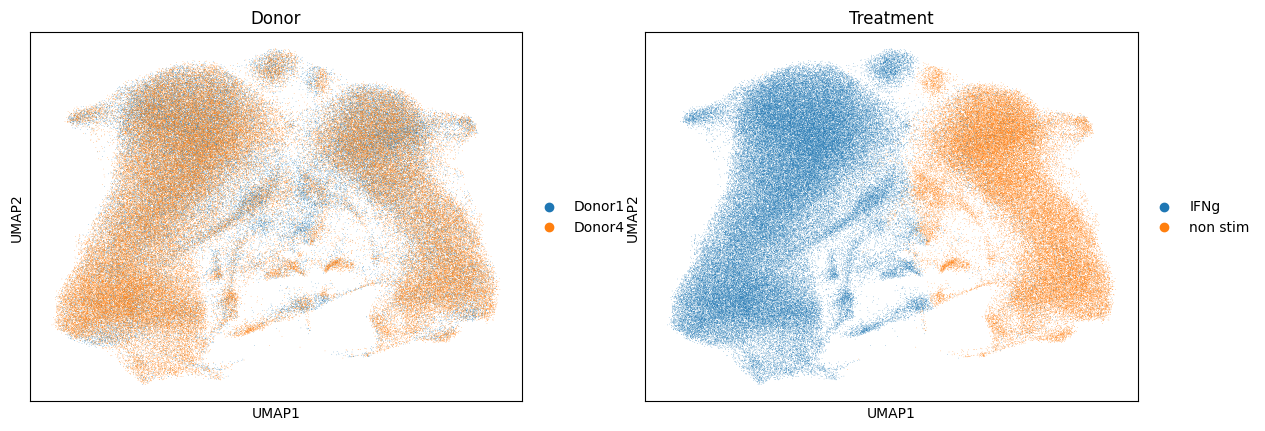

In [ ]:
sc.pl.umap(adata_subset, color = ['Donor', 'Treatment']) 

In [ ]:
adata_subset.obs['cell_type'] = adata_subset.obs['Treatment'].values

/mnt/hpcscratch/nodescratch/login01/ipykernel_2851289/3444445543.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['cell_type'] = adata.obs['Treatment'].values


In [ ]:
adata_df = adata_subset.obs[['Perturbation']].copy()
adata_df['UMAP_1'] = adata_subset.obsm['X_umap'][:, 0]
adata_df['UMAP_2'] = adata_subset.obsm['X_umap'][:, 1]
adata_df['cell_type'] = adata_subset.obs['Treatment']
adata_df.rename(columns={'Perturbation': 'gRNA'}, inplace=True)
adata_df.to_csv('../Haag_2024/metadata_per_cell.csv')
adata_subset.X = adata_subset.X.astype(np.float32)

adata.obs['Perturbation'] = adata.obs['Perturbation'].apply(lambda x : x[1:])
avg_counts = pd.DataFrame(index=adata_subset.var_names, columns=adata_subset.obs['Perturbation'].unique())
for g in adata_subset.obs['Perturbation'].unique():
    subset_adata = adata_subset[adata_subset.obs['Perturbation'] == g]
    mean_vals = subset_adata.X.mean(axis=0)
    avg_counts[g] = np.asarray(mean_vals).ravel()
avg_counts.head()
avg_counts.to_csv('../Haag_2024/pseudobulk_per_guide.csv')

In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np

# ---- 1-a.  Pull the per-cell annotation into a Series -------------------
# e.g.  'assigned_guide' might hold strings like 'sgNTC', 'sgIrf4_1', …
guides = adata.obs["Perturbation"].copy()

# ---- 1-b.  Convert guides → GENE symbols (strip 'sg' + trailing ID) -----
genes = (
    guides
    .str.replace(r"^sg",  "", regex=True)         # remove leading 'sg'
    .str.replace(r"_[0-9]+$", "", regex=True)     # drop '_1', '_2'…
    .str.replace('_ORF',"")
    .rename("gene")
)
adata.obs["Perturbation"] = genes                         # keep it for later use

# ---- 1-c.  Count how many cells per gene --------------------------------
gene_counts = genes.value_counts().rename("n_cells")  # pd.Series (index = gene)

# ---- 1-d.  Choose / verify the non-targeting control label --------------
CTRL = "NTC"          # after stripping, 'sgNTC' → 'NTC'
if CTRL not in gene_counts.index:
    raise ValueError(f"Control label '{CTRL}' not found; check naming!")

ctrl_mean = gene_counts.loc[CTRL]           # single number

# ---- 1-e.  Compute log2 fold-change vs control --------------------------
fc_tbl = (
    gene_counts
    .drop(CTRL)                                   # exclude sgNTC itself
    .to_frame()
    .assign(log2FC=lambda d: np.log2(d.n_cells / ctrl_mean))
    .sort_values("log2FC")                        # ascending: neg first
)

fc_tbl.drop(columns="n_cells", inplace=True)  # keep only log2FC

fc_tbl.to_csv('../Haag_2024/log2fc_per_gene_vs_NTC.csv')

In [ ]:
adata_df = adata.obs[['Perturbation']].copy()
adata_df['UMAP_1'] = adata.obsm['X_umap'][:, 0]
adata_df['UMAP_2'] = adata.obsm['X_umap'][:, 1]
adata_df['cell_type'] = adata.obs['Treatment']
# adata_df['cell_type'] = adata_df['cell_type'].apply(lambda x: x.split(': ')[1])
adata_df.rename(columns={'Perturbation': 'gRNA'}, inplace=True)
adata_df.to_csv('../Haag_2024/metadata_per_cell.csv')
# adata_cl13.X = adata_cl13.layers['counts']
adata.X = adata.X.astype(np.float32)
#sc.pp.normalize_per_cell(adata_cl13, counts_per_cell_after=1e4)
#sc.pp.scale(adata_cl13, zero_center=True, max_value = 4)
# I want to calculate the average expression of each gene in each assigned guide
# remove leading 'g' from adata_cl13.obs['perturbed_gene']
adata.obs['Perturbation'] = adata.obs['Perturbation'].apply(lambda x : x[1:])
avg_counts = pd.DataFrame(index=adata.var_names, columns=adata.obs['Perturbation'].unique())
for g in adata.obs['Perturbation'].unique():
    subset_adata = adata[adata.obs['Perturbation'] == g]
    mean_vals = subset_adata.X.mean(axis=0)
    avg_counts[g] = np.asarray(mean_vals).ravel()
# avg_counts = avg_counts.T
avg_counts.head()
avg_counts.to_csv('../Haag_2024/pseudobulk_per_guide.csv')